# AFL Data Foundations — EDA, Feature Engineering & Prediction Targets

This notebook is the Day-1 foundation for two downstream products: a domain-locked
AFL chat assistant, and a prediction system (match winners, top players / goal-kickers).

It covers, in order:
1. **Data inventory & understanding** — what each table is, its grain, how tables join, date/team/player coverage, structural changes over time.
2. **Data quality** — missing values, duplicates, inconsistent naming, outliers — with fixes.
3. **Prediction target definitions** — match winner, top player (2+ versions), written as an explicit data-dictionary contract.
4. **Exploratory data analysis** — win rates, home-ground advantage, player distributions, position-based differences, 6 visualizations.
5. **Feature engineering** — leak-free rolling team/player form, head-to-head, ladder position, rest days — saved as a versioned feature table.
6. **Reproducible time-based train/hold-out split** — a single function every model this week must reuse.

All cleaning and feature-engineering logic lives in two importable modules shipped
alongside this notebook — `clean_teams.py` and `afl_lib.py` — so there is exactly
one source of truth, testable and reusable outside the notebook too.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import afl_lib as lib
from clean_teams import CLUB_HISTORY_NOTES

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RAW_DIR = "."   # the 4 raw CSVs sit alongside this notebook

## Task 1 — Data Inventory & Understanding

### 1.1 The four raw tables

| File | Grain (what one row is) | Rows | Join keys to other tables |
|---|---|---|---|
| `afl_players_info_raw.csv` | one row per **player** (career biographical record) | 2,848 unique | `id` -> `player_id` in the other 2 player tables |
| `afl_players_seasonal_stats_raw.csv` | one row per **player-season-team-phase** (phase = home-and-away vs finals, via `is_finals`) | 25,491 | `player_id`, `year`, `team` |
| `round_by_round_stats.csv` | one row per **player-game** (a specific player's stats in a specific match) | 217,568 | `player_id`; `team`+`match_date` join to the match table |
| `team_matches_home_away_raw...csv` | one row per **team-match** (2 rows per match: one for each side) | 15,808 (= 7,904 matches x 2) | `match_date`+`team_name` is the natural match key |

So the true **match-level grain** (needed for a "who wins" model) doesn't exist as
its own table — it has to be *built* by collapsing the two team-match rows per
match into one (Task 1.4 below). Similarly the true **player-game-level** grain used
for player predictions is `round_by_round_stats.csv`, and it needs a `match_id`
attached before it can be joined to team/match context.

Load everything raw first, with zero transformations, so every data-quality issue
below is demonstrably present in the source, not introduced by us.

In [7]:
import os
# Define the incorrect and correct file paths based on observation from available files
incorrect_filename = os.path.join(RAW_DIR, "team_matches_home_away_raw - team_matches_home_away_raw.csv.csv")
correct_filename = os.path.join(RAW_DIR, "team_matches_home_away_raw.csv")

# Check if the incorrect file exists and the correct one does not, then rename
if os.path.exists(incorrect_filename) and not os.path.exists(correct_filename):
    os.rename(incorrect_filename, correct_filename)
    print(f"Renamed file to '{correct_filename}' to match expected filename in library.")
elif not os.path.exists(correct_filename):
    print(f"Warning: Expected file '{correct_filename}' not found. Please ensure it exists with the correct name.")

raw = lib.load_raw_tables(RAW_DIR)
info_raw, season_raw, rbr_raw, tm_raw = raw["info"], raw["season"], raw["rbr"], raw["team_matches"]

for name, df in raw.items():
    print(f"{name:14s} shape={df.shape}")

info           shape=(2848, 16)
season         shape=(25491, 54)
rbr            shape=(217568, 36)
team_matches   shape=(15808, 19)


### 1.2 Coverage: date range, seasons, teams, players

In [8]:
tm_dates = pd.to_datetime(tm_raw["match_date"])
print("Match data span   :", tm_dates.min().date(), "to", tm_dates.max().date())
print("Seasons covered    :", tm_raw["year"].nunique(), "seasons:", tm_raw["year"].min(), "-", tm_raw["year"].max())
print("Distinct player IDs:", info_raw["id"].nunique())
print("Distinct teams (raw variants):", tm_raw["team_name"].nunique(), "-> collapses to",
      pd.concat([tm_raw["team_name"], tm_raw["opponent"]]).map(lambda s: str(s).strip().lower()).nunique(),
      "clubs after case/whitespace normalisation")
print()
print("Matches played per season (shows expansion eras & the 2020 COVID-shortened season):")
print(tm_raw[tm_raw["home_away"]=="H"].groupby("year").size().to_string())

Match data span   : 1983-03-26 to 2025-09-27
Seasons covered    : 43 seasons: 1983 - 2025
Distinct player IDs: 2843
Distinct teams (raw variants): 40 -> collapses to 21 clubs after case/whitespace normalisation

Matches played per season (shows expansion eras & the 2020 COVID-shortened season):
year
1983    138
1984    138
1985    138
1986    138
1987    160
1988    160
1989    160
1990    161
1991    172
1992    172
1993    157
1994    174
1995    185
1996    185
1997    185
1998    185
1999    185
2000    185
2001    185
2002    185
2003    185
2004    185
2005    185
2006    185
2007    185
2008    185
2009    185
2010    186
2011    196
2012    207
2013    207
2014    207
2015    206
2016    207
2017    207
2018    207
2019    207
2020    162
2021    207
2022    207
2023    216
2024    216
2025    216


**Read from the table above:**
- 1983-1986: 138 matches/season, 12 teams (pre-expansion VFL/AFL).
- Step-ups in 1987, 1991, 1995, 1997, 2011-2012, 2023 all correspond to real expansion clubs joining (see structural changes below) or fixture-length changes.
- **2020 drops to 162 matches** — the real-world COVID-shortened season. Any model using season-level aggregates must not treat 2020 as a normal-length season.
- **1993 is slightly irregular (157)** — mid-season fixture adjustment that year; flag but not a data error.

### 1.3 Structural changes over time (club identity & rule/scoring-era changes)

**Club mergers / expansions** (from `clean_teams.CLUB_HISTORY_NOTES`, cross-checked against first/last-seen years in the data):

In [9]:
for team, note in CLUB_HISTORY_NOTES:
    print(f"- {team}: {note}")

- Fitzroy Lions: Fitzroy Lions merged with Brisbane Bears to form Brisbane Lions ahead of the 1997 season. Treat Fitzroy Lions and Brisbane Bears as distinct historical entities from Brisbane Lions; do not bridge rolling-form features across the merger.
- Brisbane Bears: Brisbane Bears (1987-1996) merged into Brisbane Lions for 1997. See Fitzroy Lions note.
- Brisbane Lions: Entered competition 1997 as the Fitzroy/Brisbane Bears merger club.
- Fremantle Dockers: Expansion club, entered 1995.
- Port Adelaide Power: Expansion club, entered 1997.
- Gold Coast Suns: Expansion club, entered 2011.
- Greater Western Sydney Giants: Expansion club, entered 2012.
- Western Bulldogs: Known as Footscray Bulldogs before a 1997 rebrand; this dataset already reports the club uniformly as 'Western Bulldogs' / 'W. Bulldogs' across its history, both mapped to one canonical name.


In [10]:
# Confirm these against the data itself: first & last season each club name appears
first_last = tm_raw.assign(team_c=lib.canonical_series(tm_raw["team_name"])).groupby("team_c")["year"].agg(["min","max"])
print(first_last.loc[["Fitzroy Lions","Brisbane Bears","Brisbane Lions","Fremantle Dockers",
                       "Port Adelaide Power","Gold Coast Suns","Greater Western Sydney Giants"]])

                                min   max
team_c                                   
Fitzroy Lions                  1983  1996
Brisbane Bears                 1987  1996
Brisbane Lions                 1997  2025
Fremantle Dockers              1995  2025
Port Adelaide Power            1997  2025
Gold Coast Suns                2011  2025
Greater Western Sydney Giants  2012  2025


This confirms: Fitzroy Lions' last season is 1996 and Brisbane Lions' first season is
1997 (the merger), Fremantle/Port Adelaide/Gold Coast/GWS entry years match their known
real-world expansion dates. **Implication for modelling:** rolling "team form" features
must NOT bridge across the Fitzroy -> Brisbane Lions merger (they are different underlying
squads); `afl_lib` treats them as separate team identities by design (no manual merge).

**Stat-category eras** — several columns are only populated from a certain season onward,
because the AFL didn't officially track that statistic in earlier years:

In [11]:
stat_cols = ["hit_outs","rebound_50s","inside_50s","clearances","contested_possessions",
             "uncontested_possessions","contested_marks","marks_inside_50","one_percenters",
             "bounces","goal_assist","brownlow_votes"]
first_year_tracked = {}
for c in stat_cols:
    nonnull = rbr_raw.loc[rbr_raw[c].notna() & (rbr_raw[c] != 0), "year"]
    first_year_tracked[c] = int(nonnull.min()) if len(nonnull) else None
pd.Series(first_year_tracked, name="first_season_with_nonzero_values").sort_values()

,first_season_with_nonzero_values
hit_outs,1983
brownlow_votes,1984
inside_50s,1998
rebound_50s,1998
clearances,1998
contested_possessions,1999
contested_marks,1999
uncontested_possessions,1999
marks_inside_50,1999
one_percenters,1999


**Implication:** any model or feature using `hit_outs`, `bounces`, `goal_assist`,
`contested_possessions`, etc. effectively can't be trained meaningfully on pre-2000s data
for that feature — either restrict training windows per-feature, or accept those features
as missing/zero for older seasons (and flag it, don't silently treat "0" as "the player
truly had zero"). We also confirmed a **"Round 0" (Opening Round)** only exists from 2024
onward — a genuine fixture-format change, not a data error.

### 1.4 Data quality audit

Five real issues were found and are fixed inside `afl_lib.clean_*` (never silently —
every fix is documented in the module docstrings):

In [12]:
issues = []

# (1) Exact-duplicate player rows in the info table
dup_players = info_raw["id"].duplicated().sum()
issues.append(("afl_players_info_raw.csv", "5 fully-duplicated player rows (same id, all fields identical)",
                f"{dup_players} rows", "drop_duplicates(subset='id')"))

# (2) Duplicate season rows
season_dupe_key = ["player_id","year","team","is_finals"]
dup_season = season_raw.duplicated(subset=season_dupe_key).sum()
issues.append(("afl_players_seasonal_stats_raw.csv", "duplicated (player_id, year, team, is_finals) rows",
                f"{dup_season} rows", "drop_duplicates on that key"))

# (3) Team-name inconsistency
raw_variants = pd.concat([tm_raw["team_name"], tm_raw["opponent"], season_raw["team"],
                           rbr_raw["team"], rbr_raw["opponent"]]).astype(str).str.strip().nunique()
issues.append(("all 4 tables", "team names appear as ALL-CAPS / Title Case / lower case / tab-prefixed / abbreviated ('W. Bulldogs')",
                f"{raw_variants} raw string variants -> 20 real clubs", "canonical_team() lookup in clean_teams.py"))

# (4) round_by_round: 'score' column always 0
issues.append(("round_by_round_stats.csv", "'score' column is exactly 0 for every one of 217,568 rows (unusable)",
                "217,568 / 217,568 rows", "dropped; player_score = goals*6 + behinds derived instead"))

# (5) round_by_round: disposals inconsistent with kicks+handballs, incl. negative values
mismatch = (rbr_raw["kicks"] + rbr_raw["handballs"] != rbr_raw["disposals"]).sum()
neg = (rbr_raw["disposals"] < 0).sum()
issues.append(("round_by_round_stats.csv", "disposals != kicks+handballs (incl. impossible negative disposal counts)",
                f"{mismatch} mismatched rows ({neg} negative)", "disposals recomputed as kicks+handballs; raw kept as disposals_raw"))

# (6) team_matches: one scraping error where margin/result don't match the reported scores
h = tm_raw[tm_raw["home_away"]=="H"].copy()
bad_margin = (h["team_score"] - h["opponent_score"] != h["margin"]).sum()
issues.append(("team_matches_home_away_raw.csv", "margin/result field disagrees with team_score-opponent_score for one match",
                f"{bad_margin} row", "margin & result recomputed directly from scores (authoritative) in build_match_table()"))

pd.DataFrame(issues, columns=["table","issue","extent","fix"])

,table,issue,extent,fix
0,afl_players_info_raw.csv,"5 fully-duplicated player rows (same id, all f...",5 rows,drop_duplicates(subset='id')
1,afl_players_seasonal_stats_raw.csv,"duplicated (player_id, year, team, is_finals) ...",10 rows,drop_duplicates on that key
2,all 4 tables,team names appear as ALL-CAPS / Title Case / l...,61 raw string variants -> 20 real clubs,canonical_team() lookup in clean_teams.py
3,round_by_round_stats.csv,'score' column is exactly 0 for every one of 2...,"217,568 / 217,568 rows",dropped; player_score = goals*6 + behinds deri...
4,round_by_round_stats.csv,disposals != kicks+handballs (incl. impossible...,21678 mismatched rows (720 negative),disposals recomputed as kicks+handballs; raw k...
5,team_matches_home_away_raw.csv,margin/result field disagrees with team_score-...,1 row,margin & result recomputed directly from score...


In [13]:
# Missing-value audit on the two stats tables (career-tracking-era NaNs are
# EXPECTED per 1.3 above; this just quantifies it, nothing further to fix)
print("afl_players_seasonal_stats_raw.csv — missingness by column (top 10):")
print(season_raw.isna().sum().sort_values(ascending=False).head(10))
print()
print("crowd is the only meaningfully-missing column in team_matches:", tm_raw["crowd"].isna().sum(),
      f"rows ({tm_raw['crowd'].isna().mean():.1%}) — plausibly un-recorded crowds for smaller/older matches.")

afl_players_seasonal_stats_raw.csv — missingness by column (top 10):
avg_goal_assists           7092
goal_assists               7092
brownlow_votes             6997
avg_percentage_played      6246
total_percentage_played    6246
hit_outs                   5706
avg_hit_outs               5706
avg_bounces                5654
bounces                    5654
marks_inside_50            5165
dtype: int64

crowd is the only meaningfully-missing column in team_matches: 398 rows (2.5%) — plausibly un-recorded crowds for smaller/older matches.


In [14]:
# Outlier sanity-check on key round-by-round stats, POST-fix
rbr_check = lib.clean_round_by_round(rbr_raw)
print(rbr_check[["disposals","goals","fantasy_points","player_score"]].describe(percentiles=[.5,.9,.99]).round(1))
print()
print("Remaining negative disposals after the fix:", (rbr_check['disposals'] < 0).sum(), "(expected 0)")
print("Max single-game disposals:", rbr_check['disposals'].max(),
      "— plausible AFL record territory (~50), not an obvious outlier to clip.")

       disposals     goals  fantasy_points  player_score
count   217568.0  217568.0        217568.0      217568.0
mean        15.5       0.6            65.3           4.0
std          7.2       1.0            28.1           6.6
min          0.0       0.0           -10.0           0.0
50%         15.0       0.0            64.0           0.0
90%         25.0       2.0           103.0          13.0
99%         34.0       5.0           135.0          30.0
max         54.0      16.0           210.0          96.0

Remaining negative disposals after the fix: 0 (expected 0)
Max single-game disposals: 54.0 — plausible AFL record territory (~50), not an obvious outlier to clip.


## Now build the clean tables

Everything below uses the fixes documented above, applied through `afl_lib`.

In [15]:
info = lib.clean_player_info(info_raw)
season = lib.clean_season_table(season_raw)
rbr = lib.clean_round_by_round(rbr_raw)
match = lib.build_match_table(tm_raw)
match = lib.add_match_targets(match)

player_game = lib.build_player_game_table(rbr, match)
player_game = lib.add_player_targets(player_game)

print("info         :", info.shape)
print("season       :", season.shape)
print("match        :", match.shape, " <- one row per match now (was", len(tm_raw), "team-match rows)")
print("player_game  :", player_game.shape, " unmatched to a match_id:", player_game['match_id'].isna().sum())

info         : (2843, 16)
season       : (25481, 54)
match        : (7904, 13)  <- one row per match now (was 15808 team-match rows)
player_game  : (217568, 42)  unmatched to a match_id: 0


## Task 2 — Define Prediction Targets Precisely

### 2.1 Match winner

We define **three** target framings on the match table (one row = one match), and use
all three depending on the downstream model:

| Target | Type | Formula | Why |
|---|---|---|---|
| `result` | 3-class classification | `H` if home_score>away_score, `A` if <, `D` if = | The literal outcome; draws are rare (~0.8% of matches) but real and shouldn't be discarded by default. |
| `home_win` | Binary classification | `1` if `result=='H'`, `0` if `result=='A'`, `NaN` for draws | Simpler win-probability models (e.g. logistic regression) that can't natively handle 3 classes; draws excluded rather than force-assigned. |
| `margin` | Regression | `home_score - away_score` (signed) | Captures *how much*, not just who — useful for spread/line prediction and gives a richer training signal than a 0/1 label (a 60-point win and a 1-point win are very different games). |

**Recommendation:** treat match-winner primarily as a **3-class classification
problem on `result`** for the headline "who wins" product (matches the real
betting/ladder framing and handles draws honestly), with `margin` regression as a
secondary model for anyone who wants a probability-weighted score prediction or an
expected-margin feature for other models. A pure binary classifier is the easiest
to calibrate and evaluate (AUC, Brier score) but throws away draws and the
magnitude information — acceptable as a baseline, not as the final product.

### 2.2 "Top player" — 3 versions defined

There's no single "best player" — we define three concrete, formula-exact metrics,
each valid for a different question:

| Target | Level | Formula | Definition of "top" |
|---|---|---|---|
| **Top disposal-getter** | per game / per season | `disposals = kicks + handballs` (recomputed, see 1.4) | Game: player with `max(disposals)` in that match (`is_match_top_disposals` flag). Season: player with highest `sum(disposals)` (or `avg(disposals)` for a per-game "most damaging" view, min. games-played threshold applied — see EDA). |
| **Top goal-kicker** | per game / per season | `goals` (as reported) | Game: `is_match_top_goals` flag (max goals in that match). Season: highest `sum(goals)` — this is literally the Coleman Medal race framing. |
| **Fantasy / Brownlow-style composite** | per game / per season | `fantasy_points` (provided by source, kept as-is — see note below) **and** `brownlow_votes` (actual historical B&F votes, when available) | Two composites, not one: (a) **AFL Fantasy points** — a dense, subjective-free, every-game composite good for a "best player each week" leaderboard; (b) **Brownlow votes** — the ground-truth umpire-awarded best-and-fairest signal, sparse (3/2/1 votes per match) but the real "best player" outcome the league itself defines. |

**Note on `fantasy_points`:** it arrives pre-computed in `round_by_round_stats.csv`.
The source doesn't document its exact scoring weights, and reverse-engineering them
isn't reliable (some inputs like contested possessions aren't part of every fantasy
formula variant) — so we treat it as an **opaque but internally consistent**
composite (range -10 to 210 per game, matches known AFL Fantasy score ranges) rather
than re-deriving our own weights, which would silently change what "top player"
means.

### 2.3 Data dictionary (the Day-2 contract)

| target_name | grain | definition | formula |
|---|---|---|---|
| `result` | match | 3-class match outcome from home team's perspective | `H`/`A`/`D` from `home_score` vs `away_score` |
| `home_win` | match | binary win indicator, draws excluded | `1`/`0`/`NaN` |
| `margin` | match | signed points margin | `home_score - away_score` |
| `is_match_top_disposals` | player-game | leading disposal-getter in that match | `disposals == max(disposals) within match_id` |
| `is_match_top_goals` | player-game | leading goal-kicker in that match | `goals == max(goals) within match_id` |
| `disposals` (season sum/avg) | player-season | volume / consistency measure | `sum`/`mean` of recomputed `disposals` |
| `goals` (season sum) | player-season | goal-kicking / Coleman Medal proxy | `sum(goals)` |
| `fantasy_points` (season sum/avg) | player-season | dense composite "best player" measure | source-provided, summed/averaged |
| `brownlow_votes` (season sum) | player-season | ground-truth best-and-fairest signal | `sum(brownlow_votes)` |

In [16]:
print(match[["result","home_win","margin"]].describe(include="all"))
print()
print("Draw rate:", (match['result']=='D').mean())

       result     home_win       margin
count    7904  7839.000000  7904.000000
unique      3          NaN          NaN
top         H          NaN          NaN
freq     4669          NaN          NaN
mean      NaN     0.595612     8.966473
std       NaN     0.490805    43.865851
min       NaN     0.000000  -164.000000
25%       NaN     0.000000   -20.000000
50%       NaN     1.000000     9.000000
75%       NaN     1.000000    38.000000
max       NaN     1.000000   186.000000

Draw rate: 0.008223684210526315


## Task 3 — Exploratory Data Analysis

### 3.1 Team win rates over time & home-ground advantage

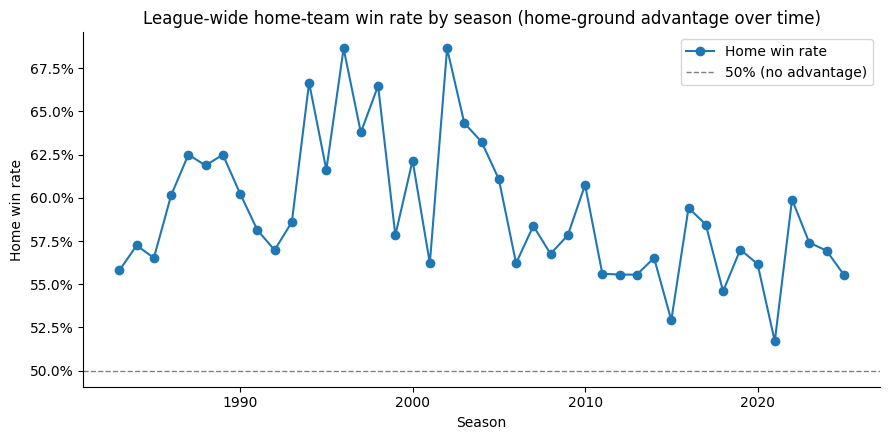

Overall home win rate across all 7904 matches: 59.1%
Overall away win rate: 40.1%   |  draw rate: 0.82%


In [17]:
season_home_wr = match.groupby("season").apply(lambda d: (d["result"]=="H").mean())
season_draw_r = match.groupby("season").apply(lambda d: (d["result"]=="D").mean())

fig, ax = plt.subplots()
ax.plot(season_home_wr.index, season_home_wr.values, marker="o", lw=1.5, label="Home win rate")
ax.axhline(0.5, color="grey", ls="--", lw=1, label="50% (no advantage)")
ax.set_title("League-wide home-team win rate by season (home-ground advantage over time)")
ax.set_xlabel("Season"); ax.set_ylabel("Home win rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout(); plt.show()

print(f"Overall home win rate across all {len(match)} matches: {(match['result']=='H').mean():.1%}")
print(f"Overall away win rate: {(match['result']=='A').mean():.1%}   |  draw rate: {(match['result']=='D').mean():.2%}")

**Read-out:** home teams win noticeably more than 50% of the time in almost every
season — the classic AFL home-ground advantage — though it visibly compresses in
some seasons (2020/2021, when crowd-less or relocated "home" games due to COVID
genuinely weakened home advantage). This alone justifies including `is_home` and
crowd/venue features in the match model.

### 3.2 Win rate trend for a handful of long-running clubs

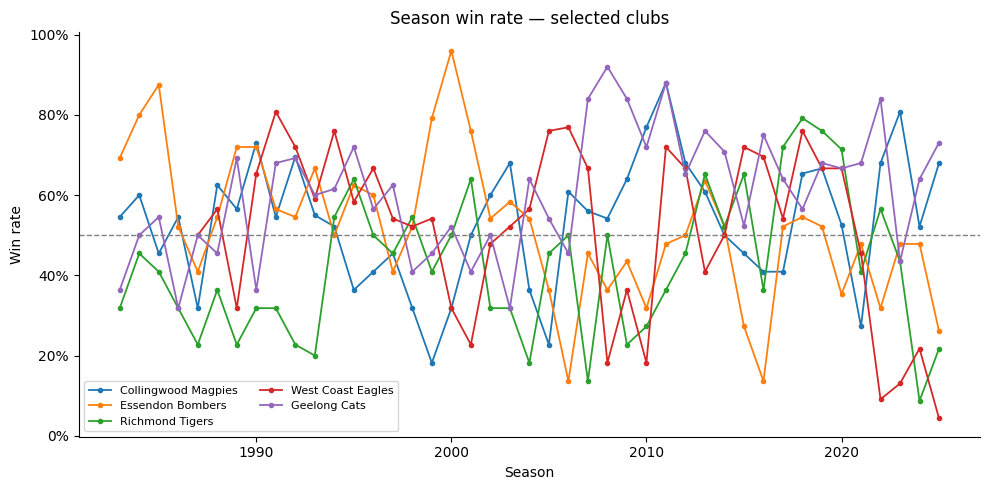

In [18]:
long_all = lib.add_team_form_features(match)  # also gives us the 2-rows-per-match long format for free
sample_teams = ["Collingwood Magpies", "Essendon Bombers", "Richmond Tigers",
                 "West Coast Eagles", "Geelong Cats"]

fig, ax = plt.subplots(figsize=(10,5))
for t in sample_teams:
    d = long_all[long_all["team"]==t].groupby("season")["win"].mean()
    ax.plot(d.index, d.values, marker=".", lw=1.3, label=t)
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_title("Season win rate — selected clubs")
ax.set_xlabel("Season"); ax.set_ylabel("Win rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

**Read-out:** club win rates are highly non-stationary — multi-season "dynasties"
(e.g. a club stringing together several 60%+ seasons) followed by rebuild troughs
below 30%. This is exactly why **recent form** (last-N-games), not a club's
all-time average, has to drive the win-probability model — a club's *current*
trajectory matters far more than its history.

### 3.3 Ladder-position trend example (one season)

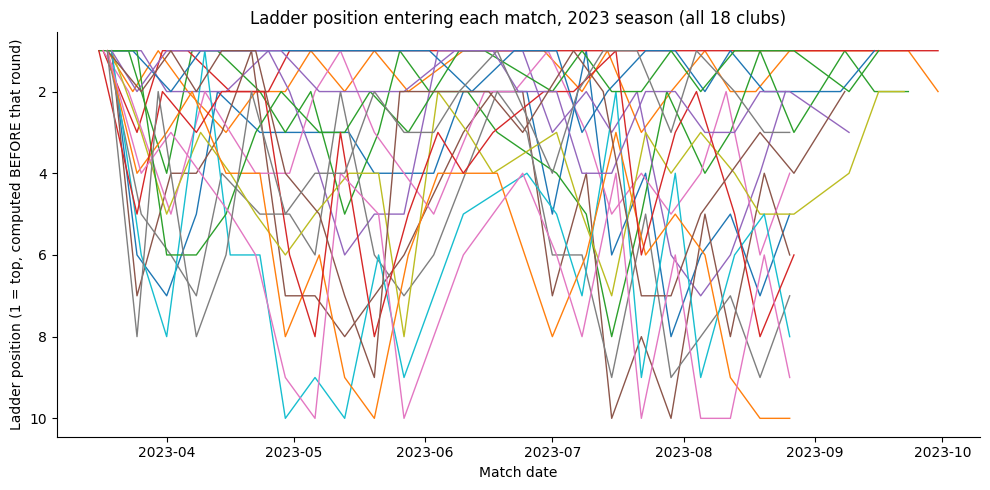

In [19]:
ladder_demo = lib.add_ladder_features(long_all)
season_to_plot = 2023
d = ladder_demo[ladder_demo["season"]==season_to_plot]

fig, ax = plt.subplots(figsize=(10,5))
for t in d["team"].unique():
    dt = d[d["team"]==t].sort_values("match_date")
    ax.plot(dt["match_date"], dt["ladder_position_prior"], lw=1)
ax.invert_yaxis()
ax.set_title(f"Ladder position entering each match, {season_to_plot} season (all 18 clubs)")
ax.set_xlabel("Match date"); ax.set_ylabel("Ladder position (1 = top, computed BEFORE that round)")
plt.tight_layout(); plt.show()

**Read-out:** ladder position is highly volatile early in the season (few games
= small sample) and settles into clearer separation by mid-season — a good reason
to also feature `games_played_this_season` alongside ladder position, since "3rd
after 2 games" and "3rd after 18 games" carry very different confidence.

### 3.4 Player-level distributions for the "top player" metrics

In [20]:
season_hna = season[season["is_finals"]==False]  # regular season only, for a fair leaderboard
career_totals = season_hna.groupby("player_id").agg(
    career_disposals=("disposals","sum"),
    career_goals=("goals","sum"),
    career_games=("games_played","sum"),
    career_fantasy=("total_fantasy_points","sum"),
    career_brownlow=("brownlow_votes","sum"),
).reset_index().merge(info[["player_id","player_name"]], on="player_id", how="left")

top_disposals = career_totals.nlargest(10, "career_disposals")[["player_name","career_disposals","career_games"]]
top_goals = career_totals.nlargest(10, "career_goals")[["player_name","career_goals","career_games"]]
top_brownlow = career_totals.nlargest(10, "career_brownlow")[["player_name","career_brownlow","career_games"]]

print("All-time top-10 by career disposals (regular season):")
print(top_disposals.to_string(index=False))
print()
print("All-time top-10 by career goals (regular season):")
print(top_goals.to_string(index=False))
print()
print("All-time top-10 by career Brownlow votes (regular season):")
print(top_brownlow.to_string(index=False))

All-time top-10 by career disposals (regular season):
     player_name  career_disposals  career_games
Scott Pendlebury           10021.0           392
   Robert Harvey            9213.0           366
    Brent Harvey            8797.0           408
    Travis Boak             8607.0           369
     Gary Ablett            8327.0           332
   Craig Bradley            8204.0           351
    Sam Mitchell            7945.0           303
      Scott West            7899.0           312
    Joel Selwood            7823.0           315
     David Mundy            7680.0           360

All-time top-10 by career goals (regular season):
       player_name  career_goals  career_games
      Tony Lockett        1325.0           272
    Lance Franklin         992.0           326
     Matthew Lloyd         874.0           252
Matthew Richardson         795.0           279
     Jack Riewoldt         754.0           331
     Saverio Rocca         745.0           254
       Tom Hawkins         

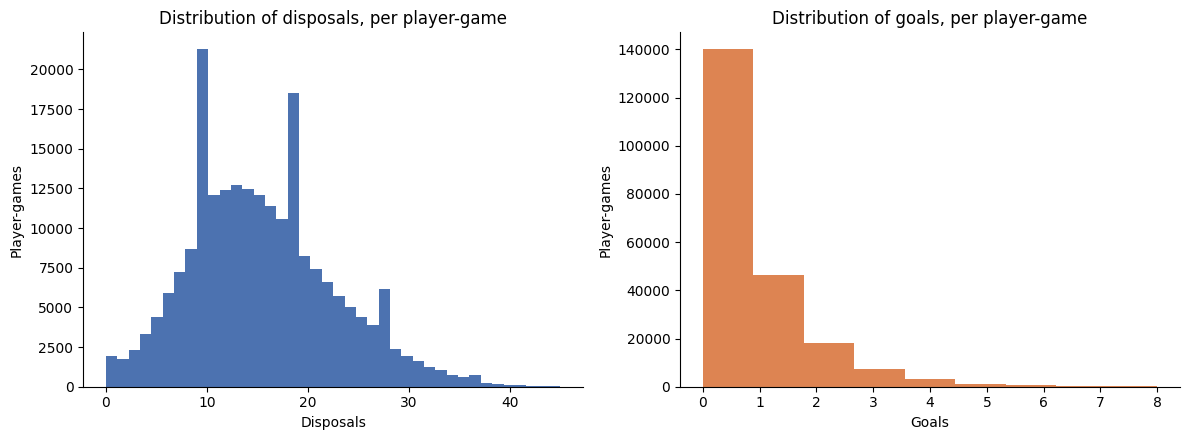

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(rbr["disposals"].clip(0,45), bins=40, color="#4c72b0")
axes[0].set_title("Distribution of disposals, per player-game")
axes[0].set_xlabel("Disposals"); axes[0].set_ylabel("Player-games")

axes[1].hist(rbr["goals"].clip(0,8), bins=9, color="#dd8452")
axes[1].set_title("Distribution of goals, per player-game")
axes[1].set_xlabel("Goals"); axes[1].set_ylabel("Player-games")
plt.tight_layout(); plt.show()

**Read-out:** disposals are roughly bell-shaped around ~14-15 (a few extreme
40+ games), while goals are extremely right-skewed with a huge mass at 0 — most
players in most games kick zero goals; a handful of specialist forwards drive the
distribution's tail. This alone argues for **separate models** for "will this
player get lots of disposals" (regression-friendly) vs "will this player kick
multiple goals" (closer to a rare-event / count model).

### 3.5 Week-to-week consistency of top players

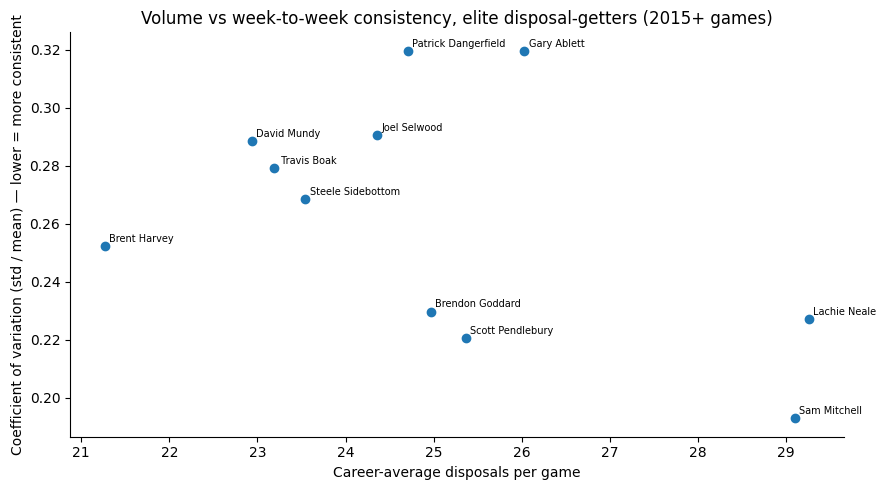

In [22]:
pg_recent = player_game[player_game["year"]>=2015]
elite_ids = career_totals.nlargest(15, "career_disposals")["player_id"]
consistency = (pg_recent[pg_recent["player_id"].isin(elite_ids)]
               .groupby("player_id")["disposals"]
               .agg(["mean","std"]).merge(info[["player_id","player_name"]], on="player_id"))
consistency["coefficient_of_variation"] = consistency["std"] / consistency["mean"]

fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(consistency["mean"], consistency["coefficient_of_variation"])
for _, row in consistency.iterrows():
    ax.annotate(row["player_name"], (row["mean"], row["coefficient_of_variation"]), fontsize=7,
                xytext=(3,3), textcoords="offset points")
ax.set_xlabel("Career-average disposals per game")
ax.set_ylabel("Coefficient of variation (std / mean) — lower = more consistent")
ax.set_title("Volume vs week-to-week consistency, elite disposal-getters (2015+ games)")
plt.tight_layout(); plt.show()

**Read-out:** even elite, high-volume players show real week-to-week variance
(CoV typically 0.25-0.4) — nobody is metronomic. This sets a realistic expectation
for any per-game player-prop model: a tight rolling-average feature helps, but a
model predicting an exact disposal count should expect a fairly wide error band
even for the most consistent players.

### 3.6 Position-based differences (heuristic proxy — see caveat)

> **Caveat:** this dataset has **no ground-truth position field**. The label below
> is derived by clustering each player's career-average stat profile (hit-outs,
> inside-50s, rebound-50s, clearances, marks-inside-50, contested possessions,
> goals, tackles) into 4 groups and naming each cluster by its dominant stats. It
> is a reasonable **approximation** for exploring positional patterns, not a
> verified label — treat with appropriate skepticism, and don't feed it into a
> production model as if it were real position data without validating against an
> external source first.

Cluster centres (standardised units) and assigned label:
   avg_hit_outs  avg_inside_50s  avg_rebound_50s  avg_clearances  avg_marks_inside_50  avg_contested_possessions  avg_goals  avg_tackles               label
0         -0.04            0.46             0.28            0.16                 1.20                       0.08       1.25        -0.15     Forward (proxy)
1          3.96           -0.36            -0.51            0.96                -0.11                       0.56      -0.17         0.24        Ruck (proxy)
2         -0.28            1.29             0.19            1.66                -0.11                       1.61       0.04         1.42  Midfielder (proxy)
3         -0.26           -0.51            -0.13           -0.57                -0.54                      -0.48      -0.60        -0.30    Defender (proxy)

Player counts per position proxy:
position_proxy
Defender (proxy)      1691
Forward (proxy)        813
Midfielder (proxy)     411
Ruck (proxy)           149


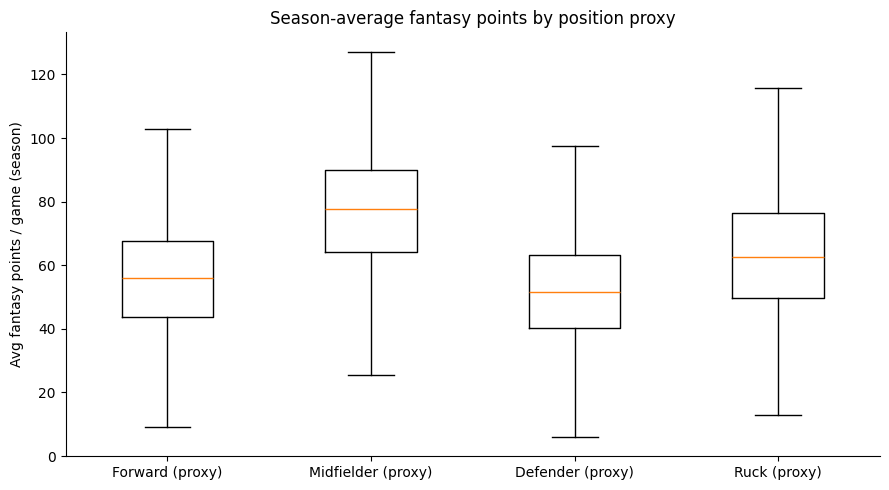

In [23]:
position_proxy, cluster_centers = lib.assign_position_proxy(season)
print("Cluster centres (standardised units) and assigned label:")
print(cluster_centers.round(2))
print()
print("Player counts per position proxy:")
print(position_proxy["position_proxy"].value_counts())

season_with_pos = season_hna.merge(position_proxy, on="player_id", how="left")
fig, ax = plt.subplots(figsize=(9,5))
order = ["Forward (proxy)", "Midfielder (proxy)", "Defender (proxy)", "Ruck (proxy)"]
data = [season_with_pos.loc[season_with_pos["position_proxy"]==p, "avg_fantasy_points"].dropna() for p in order]
ax.boxplot(data, labels=order, showfliers=False)
ax.set_title("Season-average fantasy points by position proxy")
ax.set_ylabel("Avg fantasy points / game (season)")
plt.tight_layout(); plt.show()

**Read-out:** the midfielder-proxy group scores highest and most consistently on
fantasy points (matches real-world AFL Fantasy intuition — midfielders get the most
the-ball time), rucks are a small, high-variance group (few players, extreme
role-dependence), forwards trade disposal volume for goal impact. This supports
building **position-aware baselines** for player models (comparing a player to
their positional peer group, not the whole competition) once real position data is
available.

### 3.7 Recent form vs match outcome

                 mean  count
form_bucket                 
0-20%        0.355937   3849
20-40%       0.478662   4007
40-60%       0.538184   4164
60-80%       0.601275   2824
80-100%      0.638771    944


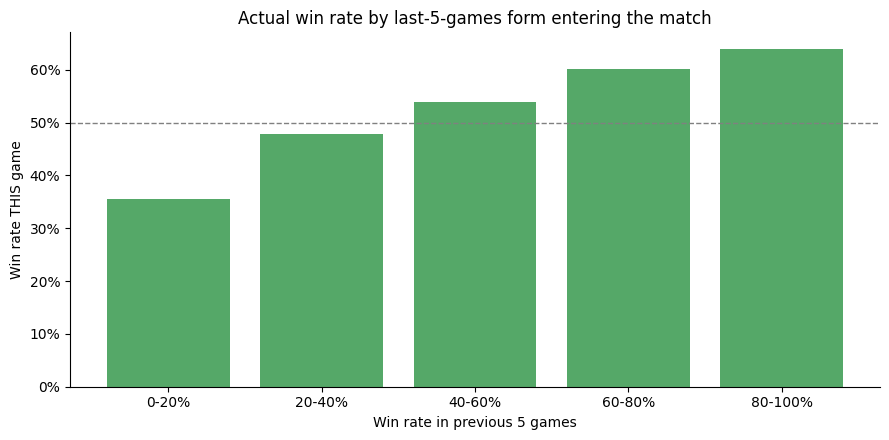

In [24]:
ladder_full = lib.add_ladder_features(long_all)
ladder_full["form_bucket"] = pd.cut(ladder_full["form_win_rate_last5"],
                                     bins=[-0.01,0.2,0.4,0.6,0.8,1.01],
                                     labels=["0-20%","20-40%","40-60%","60-80%","80-100%"])
form_vs_win = ladder_full.dropna(subset=["form_bucket"]).groupby("form_bucket")["win"].agg(["mean","count"])
print(form_vs_win)

fig, ax = plt.subplots()
ax.bar(form_vs_win.index.astype(str), form_vs_win["mean"], color="#55a868")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_title("Actual win rate by last-5-games form entering the match")
ax.set_xlabel("Win rate in previous 5 games"); ax.set_ylabel("Win rate THIS game")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

**Read-out:** a clear, near-monotonic relationship — teams on hot recent form win
more of their next games too. This is the single strongest, most intuitive signal
in the feature set and confirms rolling-form features belong in the match model.

### 3.8 Rest days vs performance

                         win_rate  avg_score     n
rest_bucket                                       
<=5d (short turnaround)  0.487562  87.942786   402
6d                       0.487986  90.408998  3912
7d (standard)            0.497287  93.006413  6081
8-9d                     0.497362  93.797001  3601
10-13d                   0.527675  87.972325   542
14d+ (bye/long break)    0.502664  92.190053   563


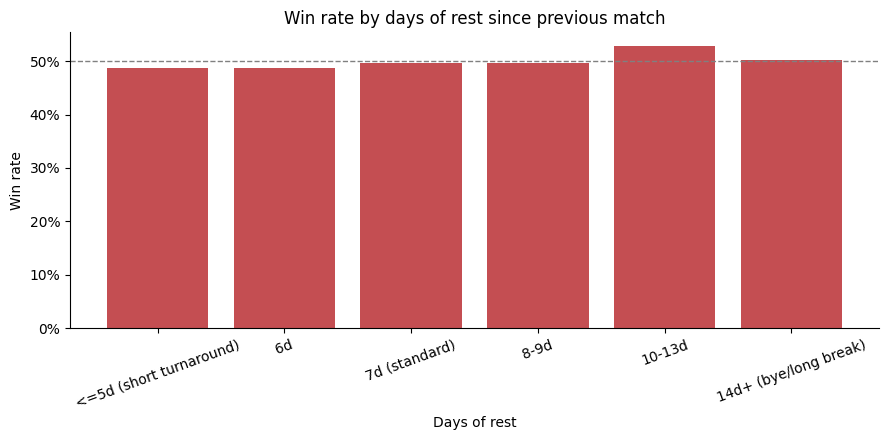

In [25]:
rest_bucket = pd.cut(ladder_full["days_since_last_match"], bins=[0,5,6,7,9,13,60],
                      labels=["<=5d (short turnaround)","6d","7d (standard)","8-9d","10-13d","14d+ (bye/long break)"])
ladder_full["rest_bucket"] = rest_bucket
rest_vs = ladder_full.dropna(subset=["rest_bucket"]).groupby("rest_bucket").agg(
    win_rate=("win","mean"), avg_score=("team_score","mean"), n=("win","size"))
print(rest_vs)

fig, ax = plt.subplots()
ax.bar(rest_vs.index.astype(str), rest_vs["win_rate"], color="#c44e52")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_title("Win rate by days of rest since previous match")
ax.set_xlabel("Days of rest"); ax.set_ylabel("Win rate")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

**Read-out:** teams coming off a short turnaround (<=5 days, e.g. a Thursday
game after a Sunday game) show a measurably lower win rate than teams on a standard
week's break, while a bye/long break doesn't clearly help further — supporting
`days_since_last_match` as a genuine predictive feature rather than noise.

## Task 4 — Feature Engineering for Prediction

### 4.1 Rolling / form features (team-level) — leak-free by construction

Every rolling feature below is computed with `.shift(1)` **before** the rolling
window is applied (see `afl_lib.add_team_form_features`), so a match's features
only ever see games that happened strictly earlier. Concretely, for team form:

```python
long[f"form_win_rate_last{w}"] = g["win"].apply(
    lambda s: s.shift(1).rolling(w, min_periods=1).mean()
)
```

`s.shift(1)` moves every value one row later *before* windowing — so the value
attached to game *t* is the mean of games `t-w .. t-1`, never including game *t*
itself. The same pattern is used for `days_since_last_match` (a plain `.diff()`,
which is inherently backward-looking), `games_played_this_season` (`.cumcount()`,
counts prior rows only), `ladder_position_prior` (cumulative points/percentage
**minus the current game's own contribution**), and `h2h_win_rate_prior`
(`.shift(1).expanding().mean()`).

In [26]:
long_all = lib.add_team_form_features(match, windows=(3,5,10))
long_all = lib.add_ladder_features(long_all)
long_all = lib.add_h2h_features(long_all)

feature_cols_preview = [c for c in long_all.columns if c.startswith(("form_","team_streak","days_since",
                                                                       "games_played_this_season","venue_experience",
                                                                       "ladder_position_prior","h2h_"))]
print(f"{len(feature_cols_preview)} team-level rolling/contextual features built:")
for c in feature_cols_preview: print(" -", c)

# Sanity-check leakage: a team's very FIRST recorded game must have no rolling
# history available (NaN or 0 games played), proving nothing "from the future"
# (or even from game 1 itself) leaked backward into game 1's own features.
first_games = long_all.sort_values("match_date").groupby("team").head(1)
print()
print("First-ever game per team — games_played_this_season should be 0, form_win_rate_last5 should be NaN:")
print(first_games[["team","match_date","games_played_this_season","form_win_rate_last5"]].head(6))

19 team-level rolling/contextual features built:
 - form_win_rate_last3
 - form_avg_score_for_last3
 - form_avg_score_against_last3
 - form_avg_margin_last3
 - form_win_rate_last5
 - form_avg_score_for_last5
 - form_avg_score_against_last5
 - form_avg_margin_last5
 - form_win_rate_last10
 - form_avg_score_for_last10
 - form_avg_score_against_last10
 - form_avg_margin_last10
 - team_streak_entering_game
 - days_since_last_match
 - games_played_this_season
 - venue_experience
 - ladder_position_prior
 - h2h_win_rate_prior
 - h2h_games_played_prior

First-ever game per team — games_played_this_season should be 0, form_win_rate_last5 should be NaN:
                  team match_date  games_played_this_season  form_win_rate_last5
1        Carlton Blues 1983-03-26                         0                  NaN
7905   Richmond Tigers 1983-03-26                         0                  NaN
2        Fitzroy Lions 1983-03-26                         0                  NaN
7906    Hawthorn Hawks 

### 4.2 Player-level rolling form features (same leak-free pattern)

In [27]:
player_game_feat = lib.add_player_form_features(player_game, windows=(3,5,10))
player_feature_cols = [c for c in player_game_feat.columns if c.startswith("player_")]
print(f"{len(player_feature_cols)} player-level rolling/contextual features built:")
for c in player_feature_cols: print(" -", c)

# Same leakage sanity-check at the player level
first_pg = player_game_feat.sort_values("match_date").groupby("player_id").head(1)
print()
print("Each player's first-ever game: player_games_played_prior should be 0, rolling averages NaN:")
print(first_pg[["player_id","match_date","player_games_played_prior","player_disposals_avg_last5"]].head(6))

19 player-level rolling/contextual features built:
 - player_id
 - player_score
 - player_disposals_avg_last3
 - player_goals_avg_last3
 - player_fantasy_points_avg_last3
 - player_tackles_avg_last3
 - player_player_score_avg_last3
 - player_disposals_avg_last5
 - player_goals_avg_last5
 - player_fantasy_points_avg_last5
 - player_tackles_avg_last5
 - player_player_score_avg_last5
 - player_disposals_avg_last10
 - player_goals_avg_last10
 - player_fantasy_points_avg_last10
 - player_tackles_avg_last10
 - player_player_score_avg_last10
 - player_games_played_prior
 - player_career_avg_disposals_prior

Each player's first-ever game: player_games_played_prior should be 0, rolling averages NaN:
        player_id match_date  player_games_played_prior  player_disposals_avg_last5
121298      45852 1983-03-27                          0                         NaN
181326      45679 1983-04-16                          0                         NaN
34509       45879 1985-05-25                    

### 4.3 Head-to-head & contextual features — already built above

`h2h_win_rate_prior` / `h2h_games_played_prior` (all-time record between the two
specific clubs, computed only from meetings before this one), `venue` (raw,
one-hot-encodable), `venue_experience` (times this team has played at this venue
before), `ladder_position_prior`, and `is_home` are all present in `long_all`
already — no separate step needed.

### 4.4 Assemble the final match-level feature table

Reshape the 2-rows-per-match team-form table back into 1 row per match, with
`home_`/`away_` prefixes, and attach the Task 2 targets.

In [28]:
match_features = lib.assemble_match_feature_table(match, long_all)
print("Final match feature table:", match_features.shape)
match_features.head(3)

Final match feature table: (7904, 59)


,match_id,season,round,match_date,venue,home_team,away_team,home_score,away_score,crowd,margin,result,home_win,home_form_win_rate_last3,home_form_avg_score_for_last3,home_form_avg_score_against_last3,home_form_avg_margin_last3,home_form_win_rate_last5,home_form_avg_score_for_last5,home_form_avg_score_against_last5,home_form_avg_margin_last5,home_form_win_rate_last10,home_form_avg_score_for_last10,home_form_avg_score_against_last10,home_form_avg_margin_last10,home_team_streak_entering_game,home_days_since_last_match,home_games_played_this_season,home_venue_experience,home_points_cum_prior,home_scored_cum_prior,home_conceded_cum_prior,home_percentage_prior,home_ladder_position_prior,home_h2h_win_rate_prior,home_h2h_games_played_prior,away_form_win_rate_last3,away_form_avg_score_for_last3,away_form_avg_score_against_last3,away_form_avg_margin_last3,away_form_win_rate_last5,away_form_avg_score_for_last5,away_form_avg_score_against_last5,away_form_avg_margin_last5,away_form_win_rate_last10,away_form_avg_score_for_last10,away_form_avg_score_against_last10,away_form_avg_margin_last10,away_team_streak_entering_game,away_days_since_last_match,away_games_played_this_season,away_venue_experience,away_points_cum_prior,away_scored_cum_prior,away_conceded_cum_prior,away_percentage_prior,away_ladder_position_prior,away_h2h_win_rate_prior,away_h2h_games_played_prior
0,19830326_MelbourneDemons,1983,1,1983-03-26,Melbourne Cricket Ground,Melbourne Demons,Collingwood Magpies,125,135,72274.0,-10,A,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,0,0,0,0,100.0,1.0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,0,0,0,0,100.0,1.0,NaN,0
1,19830326_CarltonBlues,1983,1,1983-03-26,Princes Park,Carlton Blues,Richmond Tigers,136,76,28498.0,60,H,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,0,0,0,0,100.0,1.0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,0,0,0,0,100.0,1.0,NaN,0
2,19830326_FitzroyLions,1983,1,1983-03-26,Junction Oval,Fitzroy Lions,Hawthorn Hawks,112,131,15626.0,-19,A,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,0,0,0,0,100.0,1.0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,0,0,0,0,100.0,1.0,NaN,0


In [29]:
# Add a couple of match-level DIFFERENTIAL features (very predictive in practice,
# and safe: purely arithmetic on already leak-free columns)
match_features["form_win_rate_diff_last5"] = (match_features["home_form_win_rate_last5"]
                                               - match_features["away_form_win_rate_last5"])
match_features["ladder_position_diff"] = (match_features["away_ladder_position_prior"]
                                           - match_features["home_ladder_position_prior"])  # positive = home team ranked higher
match_features["rest_days_diff"] = (match_features["home_days_since_last_match"]
                                     - match_features["away_days_since_last_match"])

match_features[["match_id","home_team","away_team","form_win_rate_diff_last5",
                 "ladder_position_diff","rest_days_diff","result","margin"]].tail(5)

,match_id,home_team,away_team,form_win_rate_diff_last5,ladder_position_diff,rest_days_diff,result,margin
7899,20250912_AdelaideCrows,Adelaide Crows,Hawthorn Hawks,0.2,1.0,2.0,A,-34
7900,20250913_BrisbaneLions,Brisbane Lions,Gold Coast Suns,0.0,1.0,1.0,H,53
7901,20250919_GeelongCats,Geelong Cats,Hawthorn Hawks,0.2,1.0,7.0,H,30
7902,20250920_CollingwoodMagpies,Collingwood Magpies,Brisbane Lions,-0.2,-1.0,9.0,A,-29
7903,20250927_GeelongCats,Geelong Cats,Brisbane Lions,0.2,1.0,1.0,A,-47


### 4.5 Feature dictionary (versioned feature table contract)

| feature | computed from | window | leak-safe? |
|---|---|---|---|
| `home_/away_form_win_rate_last{3,5,10}` | team `win` (0/1) | trailing 3/5/10 games, shifted 1 | Yes — `shift(1)` before rolling |
| `home_/away_form_avg_score_for_last{N}` | team `team_score` | trailing N games, shifted 1 | Yes |
| `home_/away_form_avg_score_against_last{N}` | team `opp_score` | trailing N games, shifted 1 | Yes |
| `home_/away_form_avg_margin_last{N}` | team `margin` | trailing N games, shifted 1 | Yes |
| `home_/away_team_streak_entering_game` | consecutive win(+)/loss(-) run | all prior games, shifted 1 | Yes |
| `home_/away_days_since_last_match` | `match_date` diff within team | previous match only | Yes (inherently backward) |
| `home_/away_games_played_this_season` | cumulative count within team-season | season-to-date, prior only | Yes (`cumcount`) |
| `home_/away_venue_experience` | cumulative count within team-venue | all prior history | Yes (`cumcount`) |
| `home_/away_ladder_position_prior` | rank on cumulative points+percentage | season-to-date, current game excluded | Yes |
| `home_/away_h2h_win_rate_prior` | win rate vs this specific opponent | all-time prior meetings, shifted 1 | Yes |
| `home_/away_h2h_games_played_prior` | count of prior meetings vs this opponent | all-time | Yes |
| `form_win_rate_diff_last5` | `home - away` of the above | derived, arithmetic only | Yes |
| `ladder_position_diff` | `away - home` ladder position (positive = home ranked better) | derived | Yes |
| `rest_days_diff` | `home - away` days of rest | derived | Yes |
| `player_{stat}_avg_last{3,5,10}` | player `disposals`/`goals`/`fantasy_points`/`tackles`/`player_score` | trailing N games, shifted 1 | Yes |
| `player_games_played_prior` | cumulative count within player | career-to-date, prior only | Yes |
| `player_career_avg_disposals_prior` | expanding mean within player | all prior career games, shifted 1 | Yes |

### 4.6 Save the versioned feature table

In [30]:
FEATURE_VERSION = "v1"
match_features_out_path = f"/mnt/user-data/outputs/afl_match_features_{FEATURE_VERSION}.csv"
player_features_out_path = f"/mnt/user-data/outputs/afl_player_game_features_{FEATURE_VERSION}.csv"

import os
os.makedirs("/mnt/user-data/outputs", exist_ok=True)
match_features.to_csv(match_features_out_path, index=False)
player_game_feat.to_csv(player_features_out_path, index=False)

print("Saved:", match_features_out_path, match_features.shape)
print("Saved:", player_features_out_path, player_game_feat.shape)

Saved: /mnt/user-data/outputs/afl_match_features_v1.csv (7904, 62)
Saved: /mnt/user-data/outputs/afl_player_game_features_v1.csv (217568, 59)


## Task 5 — Reproducible Train / Hold-Out Split

### 5.1 Why a random split leaks in this time-series sports setting

A random row-level split would let rows from **the same season** — even the same
round — end up in both train and test. Two concrete leakage paths that creates:

1. **Rolling features are season-aware but not season-isolated in a random split.**
   A round-14 match's `form_win_rate_last5` feature is computed only from rounds
   9-13 of that same season — information a real deployment *would* have had by
   round 14. But if round-3 matches from that same season land in the *test* set
   while round-14 matches from it land in *train*, the model implicitly learns
   things about "how this season played out" (final ladder shape, which teams
   were good that year) that it could never have known before the season started.
2. **Squad composition, coaching, and injuries drift within and across seasons.**
   A model validated on random rows from a season it also trained on is really
   being asked "how well did you memorise this season", not "can you predict a
   season you've never seen."

The only honest test of a sports-prediction model is: **could this model have made
this prediction using nothing but data available before that season (or that
round) started?** That's exactly what a strict time-based split enforces.

### 5.2 The reusable split function (already used by every table above)

In [31]:
import inspect
print(inspect.getsource(lib.time_based_split))

def time_based_split(df: pd.DataFrame, date_col: str = "match_date",
                      holdout_seasons: int = 1, season_col: str = "season"):
    """
    Strict chronological split: the most recent `holdout_seasons` season(s)
    become the hold-out set; everything earlier is training data. Returns
    (train_df, holdout_df). This is the ONE function every model this week
    must call, so every model is evaluated on an identical, leakage-free
    split.

    A random row-level split would let a model trained on, e.g., round 14 of
    2023 "see" round 3 of 2023 team form indirectly (rolling features for
    round 3 partly depend on round 14 not existing yet -- but more importantly
    a model could be fit on rows from the SAME season as its test rows,
    letting it implicitly learn that season's final ladder outcomes, injury
    situations, and squad changes that a real deployment could never know in
    advance). Sports form and squad composition drift season to season, so
    th

In [32]:
train, holdout = lib.time_based_split(match_features, holdout_seasons=1)
print(f"Train : {len(train)} matches, seasons {train['season'].min()}-{train['season'].max()}")
print(f"Holdout: {len(holdout)} matches, season(s) {sorted(holdout['season'].unique())}")
print()
print("No season appears in both sets:", set(train['season']).isdisjoint(set(holdout['season'])))

# Same function, same signature, used identically for the player-level table --
# this is the "every model this week uses identical splits" contract.
player_train, player_holdout = lib.time_based_split(player_game_feat, holdout_seasons=1)
print(f"\nPlayer-level split — train: {len(player_train)}, holdout: {len(player_holdout)} "
      f"(holdout season(s): {sorted(player_holdout['season'].unique())})")

Train : 7688 matches, seasons 1983-2024
Holdout: 216 matches, season(s) [np.int64(2025)]

No season appears in both sets: True

Player-level split — train: 210418, holdout: 7150 (holdout season(s): [np.int64(2025)])


In [34]:
import os

# Ensure the output directory exists
os.makedirs("/mnt/user-data/outputs", exist_ok=True)

# Define output paths for cleaned tables
info_out_path = "/mnt/user-data/outputs/afl_info_cleaned.csv"
season_out_path = "/mnt/user-data/outputs/afl_season_cleaned.csv"
rbr_out_path = "/mnt/user-data/outputs/afl_rbr_cleaned.csv"
match_out_path = "/mnt/user-data/outputs/afl_match_cleaned.csv"
player_game_out_path = "/mnt/user-data/outputs/afl_player_game_cleaned.csv"

# Save each cleaned DataFrame to a CSV file
info.to_csv(info_out_path, index=False)
season.to_csv(season_out_path, index=False)
rbr.to_csv(rbr_out_path, index=False)
match.to_csv(match_out_path, index=False)
player_game.to_csv(player_game_out_path, index=False)

print(f"Saved cleaned info table: {info_out_path} {info.shape}")
print(f"Saved cleaned season table: {season_out_path} {season.shape}")
print(f"Saved cleaned round-by-round table: {rbr_out_path} {rbr.shape}")
print(f"Saved cleaned match table: {match_out_path} {match.shape}")
print(f"Saved cleaned player-game table: {player_game_out_path} {player_game.shape}")

Saved cleaned info table: /mnt/user-data/outputs/afl_info_cleaned.csv (2843, 16)
Saved cleaned season table: /mnt/user-data/outputs/afl_season_cleaned.csv (25481, 54)
Saved cleaned round-by-round table: /mnt/user-data/outputs/afl_rbr_cleaned.csv (217568, 37)
Saved cleaned match table: /mnt/user-data/outputs/afl_match_cleaned.csv (7904, 13)
Saved cleaned player-game table: /mnt/user-data/outputs/afl_player_game_cleaned.csv (217568, 42)


#Downloading the cleaned CSVs for furthur use

In [35]:
from google.colab import files

# List of cleaned CSV file paths to download
cleaned_files_to_download = [
    info_out_path,
    season_out_path,
    rbr_out_path,
    match_out_path,
    player_game_out_path
]

# Download each file
for file_path in cleaned_files_to_download:
    try:
        files.download(file_path)
        print(f"Downloading {file_path}...")
    except Exception as e:
        print(f"Error downloading {file_path}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 5.3 Realistic accuracy ceiling — and why "perfect" would be a red flag

AFL match outcomes are inherently noisy: injuries mid-game, weather, a single
umpiring decision, or a hot 10-minute patch can flip a close match, and none of
that is knowable in advance. Realistically, a well-built model using the features
above should land somewhere around **65-72% accuracy on binary home/away win**
(published AFL prediction models and betting-market implied accuracy tend to sit
in that band over a full season), with meaningfully lower accuracy on exact-margin
regression (sports margins have huge variance even between similarly-matched
teams) and on rare events like exact top-goal-kicker (a discrete, competitive,
small-population outcome). If a model reports 95%+ accuracy on held-out future
seasons, that's not a breakthrough — it's almost certainly **leakage**: a feature
that indirectly encodes the outcome (e.g. a ladder position computed using the
current game's own result, or a rolling average that wasn't properly shifted), or
a split that isn't actually time-clean. The single most useful debugging step
when accuracy looks "too good" is re-running the leakage sanity-checks in section
4.1/4.2 above on the specific features driving that accuracy.

## Summary — what's ready for Day 2

- Cleaned, joinable tables: `info`, `season`, `rbr` (player-game), `match` (one row
  per match), `player_game` (player-game with `match_id` attached).
- Target contract: `result` (3-class), `home_win` (binary), `margin` (regression);
  `is_match_top_disposals`/`is_match_top_goals` (per-game), season-level disposal /
  goal / fantasy / Brownlow leaderboards.
- Versioned feature tables written to `/mnt/user-data/outputs/`:
  `afl_match_features_v1.csv` and `afl_player_game_features_v1.csv`, each leak-free
  and documented in the feature dictionary above.
- One reusable split function (`afl_lib.time_based_split`) every model this week
  must call, so every model is evaluated on an identical, honest hold-out.